<a href="https://colab.research.google.com/github/PragnaNunna1/assignment-02-bitsom_ba_2511521/blob/main/embeddings_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
!pip -q install sentence-transformers seaborn


In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

In [19]:
sentences = [
    # Cricket
    "The batsman scored a century in the final match.",
    "The bowler delivered a fast yorker that knocked over the stumps.",
    "The team chased the target with two overs remaining.",

    # Cooking
    "The chef simmered the tomato sauce for thirty minutes.",
    "She baked a chocolate cake with fresh cream frosting.",
    "The recipe needs garlic, onions, and olive oil.",

    # Cybersecurity
    "The security analyst detected malware in the email attachment.",
    "Strong passwords and multi-factor authentication improve account security.",
    "The firewall blocked suspicious traffic from an unknown IP address.",
    "The company responded quickly to the ransomware attack."
]

topics = [
    "Cricket", "Cricket", "Cricket",
    "Cooking", "Cooking", "Cooking",
    "Cybersecurity", "Cybersecurity", "Cybersecurity", "Cybersecurity"
]

df = pd.DataFrame({
    "sentence_id": range(1, 11),
    "topic": topics,
    "sentence": sentences
})

df

,sentence_id,topic,sentence
0,1,Cricket,The batsman scored a century in the final match.
1,2,Cricket,The bowler delivered a fast yorker that knocke...
2,3,Cricket,The team chased the target with two overs rema...
3,4,Cooking,The chef simmered the tomato sauce for thirty ...
4,5,Cooking,She baked a chocolate cake with fresh cream fr...
5,6,Cooking,"The recipe needs garlic, onions, and olive oil."
6,7,Cybersecurity,The security analyst detected malware in the e...
7,8,Cybersecurity,Strong passwords and multi-factor authenticati...
8,9,Cybersecurity,The firewall blocked suspicious traffic from a...
9,10,Cybersecurity,The company responded quickly to the ransomwar...


In [20]:
model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = model.encode(sentences)

print("Embeddings shape:", embeddings.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embeddings shape: (10, 384)


In [21]:
similarity_matrix = cosine_similarity(embeddings, embeddings)

sim_df = pd.DataFrame(
    similarity_matrix,
    index=[f"S{i}" for i in range(1, 11)],
    columns=[f"S{i}" for i in range(1, 11)]
)

sim_df.round(3)

,S1,S2,S3,S4,S5,S6,S7,S8,S9,S10
S1,1.000,0.475,0.535,0.145,0.015,-0.052,0.036,0.011,0.041,0.002
S2,0.475,1.000,0.464,0.196,0.084,0.003,0.048,0.032,0.088,0.132
S3,0.535,0.464,1.000,0.121,-0.065,-0.007,0.075,-0.016,0.203,0.169
S4,0.145,0.196,0.121,1.000,0.159,0.321,0.115,-0.076,0.164,0.287
S5,0.015,0.084,-0.065,0.159,1.000,0.174,0.063,-0.059,0.049,0.080
S6,-0.052,0.003,-0.007,0.321,0.174,1.000,0.003,-0.068,0.040,0.026
S7,0.036,0.048,0.075,0.115,0.063,0.003,1.000,0.219,0.348,0.410
S8,0.011,0.032,-0.016,-0.076,-0.059,-0.068,0.219,1.000,0.036,0.112
S9,0.041,0.088,0.203,0.164,0.049,0.040,0.348,0.036,1.000,0.327
S10,0.002,0.132,0.169,0.287,0.080,0.026,0.410,0.112,0.327,1.000


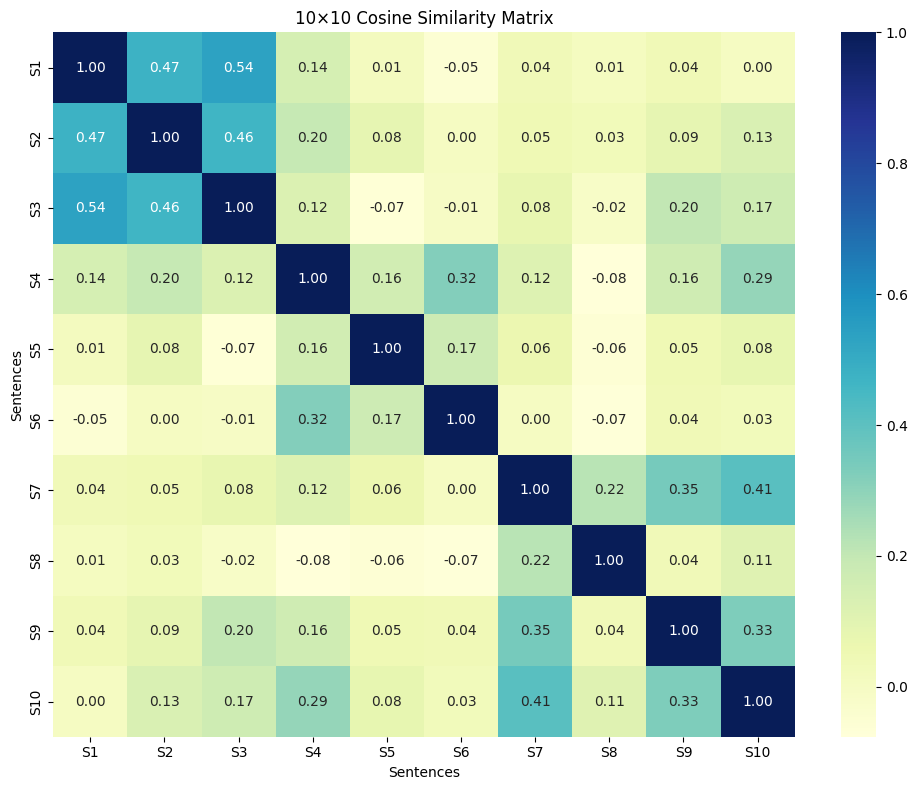

In [22]:
plt.figure(figsize=(10, 8))
sns.heatmap(sim_df, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("10×10 Cosine Similarity Matrix")
plt.xlabel("Sentences")
plt.ylabel("Sentences")
plt.tight_layout()
plt.show()

In [23]:
query_sentence = "The bowler took three wickets in one over"
query_embedding = model.encode([query_sentence])

query_similarities = cosine_similarity(query_embedding, embeddings)[0]

results = pd.DataFrame({
    "sentence": sentences,
    "topic": topics,
    "similarity_score": query_similarities
}).sort_values(by="similarity_score", ascending=False).reset_index(drop=True)

top2 = results.head(2)
top2

,sentence,topic,similarity_score
0,The bowler delivered a fast yorker that knocke...,Cricket,0.647521
1,The batsman scored a century in the final match.,Cricket,0.567912


In [24]:
print("Query sentence:", query_sentence)
print("\nTop 2 most similar sentences:\n")

for i, row in top2.iterrows():
    print(f"{i+1}. [{row['topic']}] {row['sentence']}")
    print(f"   Similarity score: {row['similarity_score']:.4f}")

Query sentence: The bowler took three wickets in one over

Top 2 most similar sentences:

1. [Cricket] The bowler delivered a fast yorker that knocked over the stumps.
   Similarity score: 0.6475
2. [Cricket] The batsman scored a century in the final match.
   Similarity score: 0.5679
